# 08 Profile modelling: 2D polygons, manual fit, least squares

Filters describe the field. Modelling asks what bodies could produce it.
`potfield.model2d` computes gravity and total field anomalies of polygonal
bodies with infinite strike length perpendicular to a profile, the classic
Talwani approach used by every 2D modelling package. It is exact for the
2D assumption and adequate when the strike length is several times the
depth and the profile crosses the strike at a right angle.

Coordinates: x is distance along the profile in metres, z is depth in
metres, positive down. Bodies must lie below the observation points.

Gravity, with q = x + i z the position of a boundary point relative to the
observation point, a and b the ends of an edge and d = b - a:

    g_x + i g_z = -i G rho sum_edges [ (d / conj d) conj(b ln b - a ln a) - d ]

Magnetics, from the equivalent surface pole density sigma = M . n on each
edge with unit tangent e:

    B_x + i B_z = -2 Cm sigma e conj(ln(b / a))

The total field anomaly is f . B with f the ambient field direction
projected onto the profile plane. Along-strike components of both M and f
drop out in 2D, so the effective inclination depends on the profile
azimuth: a profile perpendicular to the declination sees a nearly vertical
field and symmetric anomalies. Induced magnetisation is kappa F / mu0;
remanence can be added per body.

Both kernels are tested against a line mass, a line dipole and a thin
sheet in `tests/test_model2d.py`, and against each other through
Poisson's relation.

Ambient field for the Frome area at 2015.0 (IGRF-13): I = -62.4,
D = 7.5, F = 56671 nT. The aeromagnetic compilation was flown at about
60 to 100 m, so the observation height is set to 80 m (z = -80).

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

In [2]:
from potfield import model2d
from potfield.synthetic import G

F_NT = 56671.0      # IGRF total intensity, nT
Z_OBS = -80.0       # sensor 80 m above ground, z positive down

## Check against closed forms

A 180-sided polygon stands in for a horizontal cylinder, whose external
field is exactly that of a line mass and a line dipole.

gravity: max misfit / peak = 2.6880158627948895e-14


Text(0.5, 1.0, 'same cylinder, I = -62.4 D = 7.5: the skew depends on profile direction')

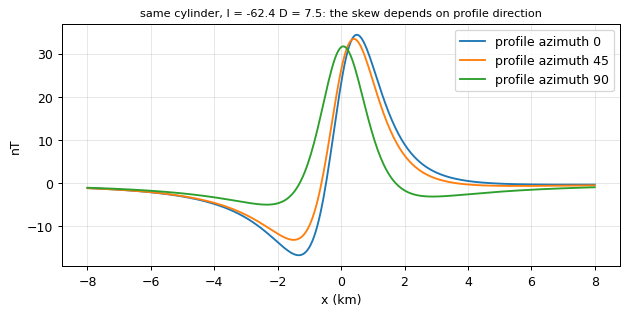

In [3]:
cyl = model2d.circle(0.0, 1500.0, 400.0, n=180, density=500.0, susceptibility=0.02)
x = np.linspace(-8000.0, 8000.0, 321)
g = model2d.gravity([cyl], x)
g_exact = 1e5 * 2 * G * 500.0 * cyl.area * 1500.0 / (x**2 + 1500.0**2)
print("gravity: max misfit / peak =", np.max(np.abs(g - g_exact)) / g_exact.max())

fig, ax = plt.subplots(figsize=(8, 3.5))
for az in (0, 45, 90):
    t = model2d.magnetic([cyl], x, INC, DEC, az, F_NT)
    ax.plot(x / 1e3, t, label=f"profile azimuth {az}")
ax.set_xlabel("x (km)"); ax.set_ylabel("nT"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("same cylinder, I = %.1f D = %.1f: the skew depends on profile direction" % (INC, DEC), fontsize=9)

## Observed profiles

An east-west line across the Frome Embayment south of Lake Frome, over
cover, with two broad magnetic highs and a gravity high near the eastern
one. Basement bodies a few kilometres down are the target.

52.5 km, azimuth 89.3 deg, 609 TMI samples, 264 gravity samples


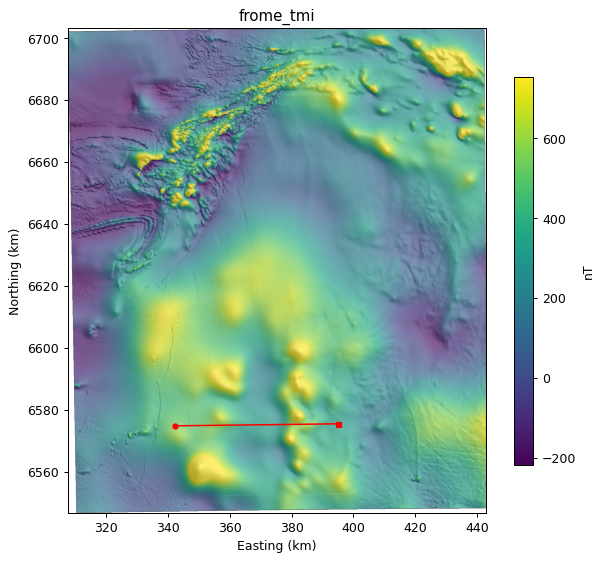

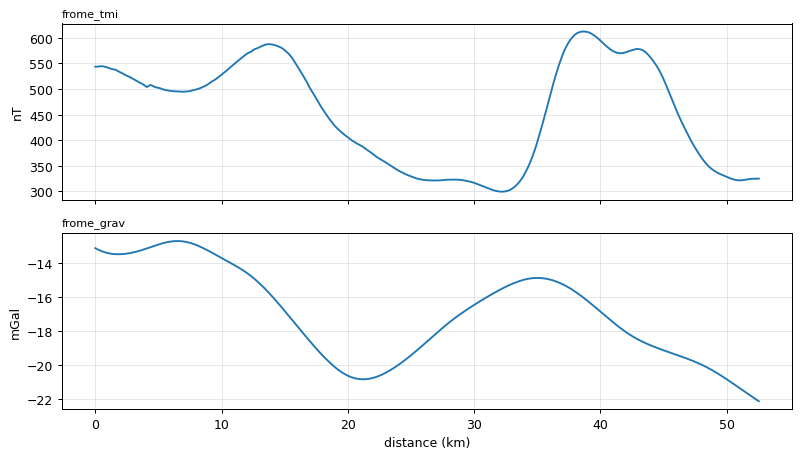

In [4]:
tmi = read_grid(f"{DATA}/frome_tmi.ers", epsg=28354, units="nT")
grav = read_grid(f"{DATA}/frome_grav.ers", units="mGal")
line = ((139.35, -30.95), (139.90, -30.95))                   # lon, lat
pt = tmi.profile(*line, epsg=4283)
pg = grav.profile(*line, epsg=4283)
print(f"{pt.length / 1e3:.1f} km, azimuth {pt.azimuth:.1f} deg, {len(pt)} TMI samples, {len(pg)} gravity samples")

fig, ax = plt.subplots(figsize=(8, 7))
display.plot(tmi, ax=ax, cmap="viridis", clip=("std", 2.0), shade={"azimuth": 45})
display.plot_line(ax, pt, color="r")

x = pt.distance[::2]                       # one sample per 170 m is plenty
obs_tmi = pt.values[::2]
obs_grav = np.interp(x, pg.distance, pg.values)
fig, axes = display.plot_profiles([pt, pg])

## Manual model: edit and rerun

Bodies are a Python list. `dyke` builds a parallelogram from centre, top,
width, dip and vertical extent; `rectangle` and `Body` (any polygon) also
work. Change the numbers, run the cell, look at the misfit, repeat. A
linear regional is fitted to the residual so the bodies only have to
explain the anomalies.

Rules of thumb to start: the half-width of a broad anomaly is close to the
depth to the top of a wide body; the amplitude scales with susceptibility
times width.

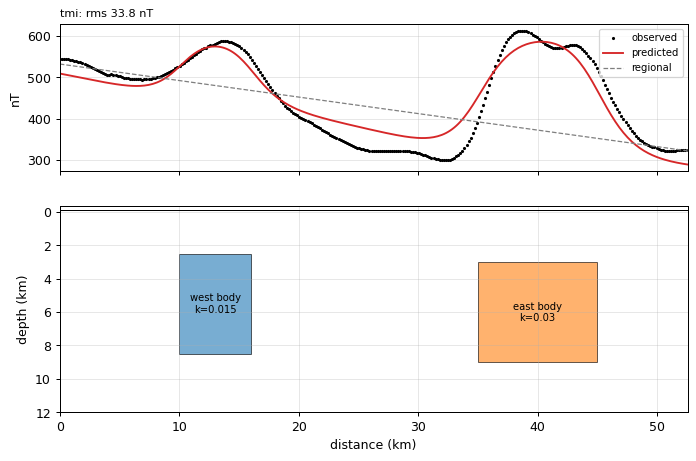

In [5]:
bodies = [
    model2d.dyke(x_centre=13000, top=2500, width=6000, dip=90, extent=6000, susceptibility=0.015, name="west body"),
    model2d.dyke(x_centre=40000, top=3000, width=10000, dip=90, extent=6000, susceptibility=0.03, name="east body"),
]
pred = model2d.magnetic(bodies, x, INC, DEC, pt.azimuth, F_NT, z_obs=Z_OBS)
reg = model2d.regional(x, obs_tmi - pred, order=1)
fig, axes = model2d.plot_model(x, {"tmi": obs_tmi}, {"tmi": pred + reg}, bodies, z_obs=Z_OBS,
                               regional_part={"tmi": reg}, depth_max=12000)

## Least squares

`fit` takes a function that builds the bodies from a parameter vector, a
starting point and bounds, and runs `scipy.optimize.least_squares`. The
regional is solved linearly inside every evaluation, so only the body
parameters are nonlinear. Here the vertical extent is fixed at 6 km and
eight parameters are free: centre, top, width and susceptibility of each
body.

             xc1 =    1.336e+04
            top1 =         2265
              w1 =         6804
              k1 =      0.01494
             xc2 =    4.089e+04
            top2 =         2836
              w2 =    1.126e+04
              k2 =      0.03449
             rms =        24.06


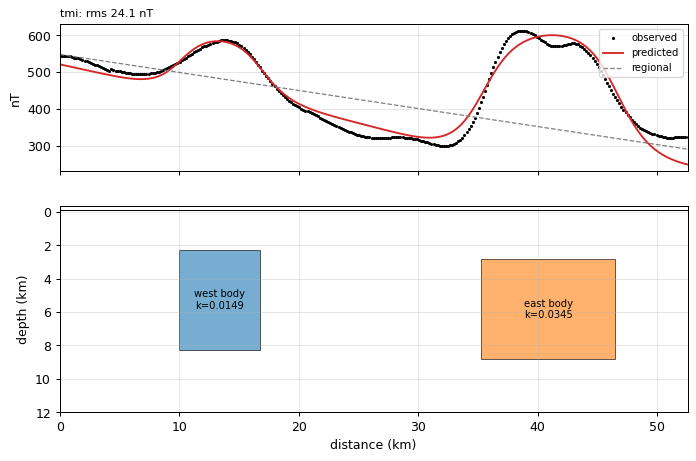

In [6]:
EXTENT = 6000.0

def build(p):
    return [
        model2d.dyke(p[0], p[1], p[2], 90.0, EXTENT, susceptibility=p[3], name="west body"),
        model2d.dyke(p[4], p[5], p[6], 90.0, EXTENT, susceptibility=p[7], name="east body"),
    ]

names = ["xc1", "top1", "w1", "k1", "xc2", "top2", "w2", "k2"]
p0 = [13000, 2500, 6000, 0.015, 40000, 3000, 10000, 0.03]
lo = [0, 200, 500, 0.0, 20000, 200, 500, 0.0]
hi = [20000, 8000, 20000, 0.3, 50000, 8000, 20000, 0.3]
res = model2d.fit(x, obs_tmi, build, p0, field_name="tmi", bounds=(lo, hi), regional_order=1,
                  z_obs=Z_OBS, inc=INC, dec=DEC, azimuth=pt.azimuth, field_nt=F_NT)
print(res.summary(names))
fig, axes = model2d.plot_model(x, {"tmi": obs_tmi}, {"tmi": res.predicted}, res.bodies, z_obs=Z_OBS,
                               regional_part={"tmi": res.regional}, depth_max=12000)

## Non-uniqueness

The fit is only as unique as the assumptions. Repeat it with the vertical
extent fixed at 3 km and at 12 km. The misfit barely changes while the
tops and susceptibilities move: a thinner body needs more susceptibility
to give the same amplitude, and depth trades against width. Any of these
models is acceptable from the profile alone; geology, drilling or the
gravity has to break the tie.

In [7]:
rows = []
for extent in (3000.0, 6000.0, 12000.0):
    def build_e(p, extent=extent):
        return [model2d.dyke(p[0], p[1], p[2], 90.0, extent, susceptibility=p[3], name="west body"),
                model2d.dyke(p[4], p[5], p[6], 90.0, extent, susceptibility=p[7], name="east body")]
    r = model2d.fit(x, obs_tmi, build_e, p0, field_name="tmi", bounds=(lo, hi), regional_order=1,
                    z_obs=Z_OBS, inc=INC, dec=DEC, azimuth=pt.azimuth, field_nt=F_NT)
    rows.append((extent, r.rms, *r.params))
print(f"{'extent':>8} {'rms':>6}  " + "  ".join(f"{n:>8}" for n in names))
for row in rows:
    print(f"{row[0]:8.0f} {row[1]:6.1f}  " + "  ".join(f"{v:8.3g}" for v in row[2:]))

  extent    rms       xc1      top1        w1        k1       xc2      top2        w2        k2
    3000   24.3  1.34e+04  2.98e+03  6.82e+03    0.0263  4.09e+04  3.76e+03  1.13e+04    0.0643
    6000   24.1  1.34e+04  2.26e+03   6.8e+03    0.0149  4.09e+04  2.84e+03  1.13e+04    0.0345
   12000   24.0  1.33e+04  1.73e+03  6.77e+03    0.0107  4.09e+04  2.01e+03  1.11e+04    0.0225


## Bring in the gravity

Keep the magnetic geometry and ask what density contrast each body needs
to explain the gravity profile. With the geometry fixed this is linear in
the two densities.

        rho west =       -8.721
        rho east =        48.22
             rms =        1.629


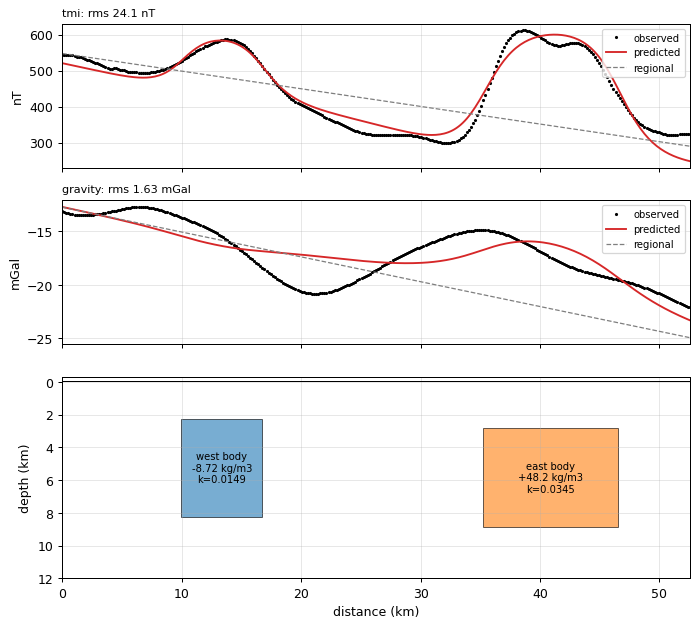

In [8]:
def build_grav(p):
    return [model2d.Body(b.x, b.z, density=p[i], susceptibility=b.susceptibility, name=b.name) for i, b in enumerate(res.bodies)]

resg = model2d.fit(x, obs_grav, build_grav, [100.0, 100.0], field_name="gravity",
                   bounds=([-500.0, -500.0], [500.0, 500.0]), regional_order=1)
print(resg.summary(["rho west", "rho east"]))
fig, axes = model2d.plot_model(x, {"tmi": obs_tmi, "gravity": obs_grav}, {"tmi": res.predicted, "gravity": resg.predicted},
                               resg.bodies, z_obs=Z_OBS, regional_part={"tmi": res.regional, "gravity": resg.regional}, depth_max=12000)

The western body carries the magnetic anomaly but needs no density
contrast; the eastern one is both magnetic and denser than its
surroundings. That is the same statement notebook 06 made statistically
with the Poisson correlation, now made body by body. A joint fit that
lets the geometry move to satisfy both profiles is the next step; with
this module it is a `build` function that returns bodies with both
properties and a residual that stacks the two fields.

Save the model so it can be reloaded or shared.

In [9]:
import os
os.makedirs(OUT, exist_ok=True)
print(model2d.save_bodies(resg.bodies, f"{OUT}/frome_lineC_model.json"))
print(model2d.load_bodies(f"{OUT}/frome_lineC_model.json")[1])

..\outputs\frome_lineC_model.json
Body(x=array([35258.99195093, 46514.31063134, 46514.31063134, 35258.99195093]), z=array([2836.49131299, 2836.49131299, 8836.49131299, 8836.49131299]), density=48.223923145053064, susceptibility=0.034490816132554024, magnetisation=0.0, mag_inc=None, mag_dec=None, name='east body', reference_density=0.0)
